In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # vecinos más cercanos para clasificación
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.metrics import classification_report


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.feature_selection import SequentialFeatureSelector, RFECV, SelectFromModel
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
import joblib
from sklearn import set_config
from lcode import MCFeatureEngineer, get_bmi, get_AST_ALT_Ratio, get_eyesight_mean, get_TG_HDL_Ratio, get_MAP, get_Non_HDL_Cholesterol, get_Pulse_Pressure, get_WHtR

set_config(transform_output="pandas")

Primero el dataset para poder probar individualmente partes si es necesario

In [5]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
X = df_smokers[df_smokers.columns.drop("smoking")]
y = df_smokers["smoking"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [6]:
pulse_pl = Pipeline(steps=[
    ("pulse_pressure",  MCFeatureEngineer(new_feature_name="Pulse_Pressure", drop_features=False,  operation=get_Pulse_Pressure)),
    ("MAP",  MCFeatureEngineer(new_feature_name="MAP", drop_features=False,  operation=get_MAP)),
])

ct1 = ColumnTransformer(
        transformers=[
            ("BMI", MCFeatureEngineer(new_feature_name="BMI", drop_features=True,  operation=get_bmi), ['height(cm)', 'weight(kg)']),
            ("WHtR", MCFeatureEngineer(new_feature_name="WHtR", drop_features=True,  operation=get_WHtR), ['Cholesterol', 'HDL']),
            ("TG_HDL_Ratio", MCFeatureEngineer(new_feature_name="TG_HDL_Ratio", drop_features=True,  operation=get_TG_HDL_Ratio), ['triglyceride', 'HDL']),
            ("Non_HDL_Cholesterol", MCFeatureEngineer(new_feature_name="Non_HDL_Cholesterol", drop_features=True,  operation=get_Non_HDL_Cholesterol), ['Cholesterol', 'HDL']),
            #("Pulse_Pressure", MCFeatureEngineer(new_feature_name="Pulse_Pressure", drop_features=False,  operation=get_Pulse_Pressure), ['systolic','relaxation']),
            # Entiendo que es mas prolijo y natural poner la linea de trabajo en un pipeline, graficar para mayor entendimiento
            ("Pulse_PL", pulse_pl, ['systolic','relaxation']),
            ("AST_ALT_Ratio", MCFeatureEngineer(new_feature_name="AST_ALT_Ratio", drop_features=False,  operation=get_AST_ALT_Ratio), ['AST','ALT']) 
        ],
        verbose_feature_names_out=False,
        remainder="passthrough"
    )



In [ ]:
# 1. Probar solo el ColumnTransformer
ct1.fit(X_train, y_train)
# 2. Si ct1 funciona sin error, transformar los datos
#X_trans = ct1.transform(X_train)

In [50]:
#dsr = ct1.fit_transform(X_train, X_test)
#dsr.isnull().sum()
#dsr.shape

In [ ]:
pl = Pipeline(steps=[
    ("CT1", ct1),
    ("rf_clf", RandomForestClassifier()),
],
memory=joblib.Memory(location=None))

#Agrego el estimador
param_grid = {
    'rf_clf__criterion': ['gini', 'entropy', 'log_loss'],
    'rf_clf__max_depth': [3,4,5,6],
    'rf_clf__min_samples_split': [10,20,30,40],
    'rf_clf__max_features': ["sqrt", "log2"], #Que cantidad de variables tomo?
    'rf_clf__n_estimators':[30,60,90]
    #'min_impurity_decrease': []
}
#gs = GridSearchCV(estimator=pl, param_grid=param_grid, scoring="accuracy", cv=5, n_jobs=-1)
gs = GridSearchCV(estimator=pl, param_grid=param_grid, scoring="accuracy", cv=5, error_score='raise', n_jobs=-1)
gs.fit(X_train, y_train)
gs.best_estimator_


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('CT1', ...), ('rf_clf', ...)]"
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(location=None)
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','height(cm)','weight(kg)',...,'ALT','Gtp','dental caries']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('BMI', ...), ('WHtR', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [16]:
gs.best_score_

np.float64(0.7305928848837902)

In [17]:
best  = gs.best_estimator_[-1]

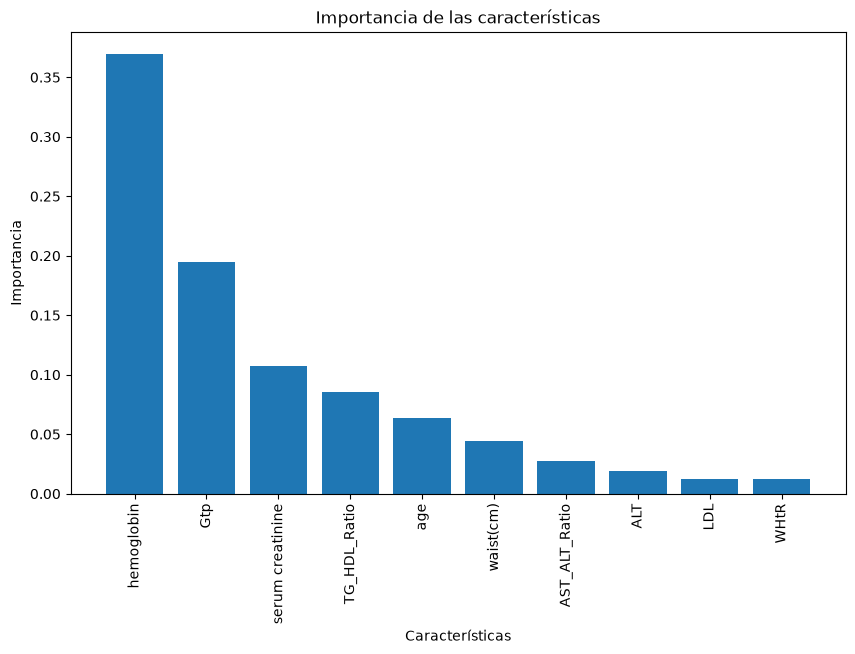

In [18]:

feature_names = best.feature_names_in_
importances = best.feature_importances_
# Ordenar las características por importancia
indices = np.argsort(importances)[::-1]
sorted_feature_names = feature_names[indices]
sorted_importances = importances[indices]
max_values = 10
plt.figure(figsize=(10, 6))
plt.title("Importancia de las características")
plt.bar(range(max_values), sorted_importances[:max_values], align="center")
plt.xticks(range(max_values), sorted_feature_names[:max_values], rotation=90)
plt.xlabel("Características")
plt.ylabel("Importancia")
plt.show()

In [21]:
gs.best_estimator_.named_steps['sfs_clf'].selected_features_


KeyError: 'sfs_clf'

Usar joblib o picke para salvar el modelo

In [ ]:
joblib.dump(pipeline, 'model.joblib')
#model = joblib.load("model.joblib")

In [ ]:
# 2. Extraer el paso del SequentialFeatureSelector ('sfs')
sfs_step = best_pipeline.named_steps['sfs']

# 3. Obtener la máscara booleana de características seleccionadas
mask = sfs_step.get_support()

# 4. Obtener los nombres de las columnas si X es un DataFrame de Pandas
columnas_seleccionadas = X.columns[mask].tolist()

In [ ]:
#shutil.rmtree('./pipeline_cache')

In [ ]:
pl.steps = pl.steps[:-1]
pl.fit(X_train)
X_train_tr = pl.transform(X_train)
X_test_tr  = pl.transform(X_test)

In [ ]:
X_test_tr.columns

In [ ]:
min_features = 3
max_features = 3

#usando SFS. demora 156 minutos, ['age','hemoglobin','Gtp'] 
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
X = df_smokers[df_smokers.columns.drop("smoking")]
y = df_smokers["smoking"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

pl = Pipeline(steps=[
    ("CT1", ct1),
    ("CT2", ct2),
    ("scaler", MinMaxScaler()),
    ("efs",  EFS(KNeighborsClassifier(), min_features=min_features, max_features=max_features, scoring='accuracy', cv=5, print_progress=True)),
    ("clf", KNeighborsClassifier())
],
memory=joblib.Memory(location=None))

#Agrego el estimador
param_grid = {
    "clf__n_neighbors": [31,35,45],
    "efs__n_neighbors": [31,35,45],
}


gs = GridSearchCV(estimator=pl, param_grid=param_grid, scoring="accuracy", cv=5, n_jobs=-1)
gs.fit(X_train, y_train)
gs.best_estimator_

"""
efs = efs.fit(X_train_tr, y_train)

print('Mejor combinación de índices:', efs.best_idx_)
print('Mejor puntaje:', efs.best_score_)
X_train.iloc[:, list(efs.best_idx_)]
"""



In [ ]:
sfs = SequentialFeatureSelector(KNeighborsClassifier(n_neighbors=11), n_features_to_select=3, scoring="accuracy", cv=5, direction="backward", n_jobs=-1)
sfs.fit(X_train_tr, y_train)
sfs.get_feature_names_out()

In [ ]:

X_train_efs = efs.transform(X_train_tr)
X_test_efs = efs.transform(X_train_tr)

In [ ]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
X = df_smokers[df_smokers.columns.drop("smoking")]
y = df_smokers["smoking"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

pl = Pipeline(steps=[
    ("CT1", ct1),
    ("CT2", ct2),
    ("scaler", MinMaxScaler())    
],
memory='./pipeline_cache')

#Agrego el estimador
param_grid = {
    "clf__n_neighbors":[5,9,15,31,35]
}
pl.steps.append(("clf", KNeighborsClassifier()))
gs = GridSearchCV(estimator=pl, param_grid=param_grid, scoring="accuracy", cv=5, n_jobs=-1)
gs.fit(X_train, y_train)
gs.best_estimator_


In [ ]:
"""
X['Remnant_Cholesterol'] = X['Cholesterol'] - X['HDL'] - X['LDL']
# 3. Presión Arterial


# 4. Enzimas Hepáticas
X['AST_ALT_Ratio'] = X['AST'] / (X['ALT'] + self.eps)

# 5. Visión y Audición
X['eyesight_mean'] = (X['eyesight(left)'] + X['eyesight(right)']) / 2.0
X['eyesight_diff'] = (X['eyesight(left)'] - X['eyesight(right)']).abs()
X['hearing_any_loss'] = ((X['hearing(left)'] == 2) | (X['hearing(right)'] == 2)).astype(int)
"""

# Análisis Exploratorio

In [ ]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
df_smokers.head(5)

1.Ya sabemos de practicas anteriores que no tiene nulos y ademas los tipos son int y float. Desde ese punto de vista los datos son sanos y no requieren intervención.  
2.Tambien sabemos que hay variables con alta tasa de correlación.

Arranquemos con ingenieria de caracteristicas.  
IMC / BMI : Peso en kilos / (Altura en cm / 100)**2  
Cintura-Estatura: waist(cm)/height(cm)
Colesterol total: Colesterol / HDL  
Trigliceridos HDL : Trigriceridos / HDL  
Colesterol no hdl : Colesterol - HDL  
Remanente lipidos: Colesterol - HDL - LDL  
Sistolica: relaxation + ((Systolic-relaxation)/3)  
Presion pulso: Sistolica - relaxation   
Cociente de De Ritis: AST/ALT  
Core Hepático Combinado: PCA para Gtp, AST y ALT.
Vision promedio y diferencia, ojos iz + der / 2 y abs(iz-der)
 



In [ ]:
df_smokers.columns

Vamos con las transformaciones pero ¿Function transformers o Custom Transformers? Ambas son válidas. Criterio personal, transformaciones simples FunctionTransformer+lambda. Transformaciones 1 a 1, es una cuenta sobre el registro que no involucra al resto del dataset 


In [ ]:
ct_bmi = ("BMI", FunctionTransformer() )

# Correlación de Variables

In [ ]:
plt.figure(figsize=(14,7))
sns.heatmap(df_smokers.corr(), annot=True, vmax=.7, cmap ='Blues', fmt=".2f")

In [ ]:
df_smokers_corr = df_smokers.corr()[["smoking"]]*100 # lo pasamos a porcentajes
df_smokers_corr = df_smokers_corr.drop("smoking", axis=0) # eliminamos la variable target
df_smokers_corr = df_smokers_corr.sort_values(["smoking"], ascending=False) # ordenamos en forma descendente
df_smokers_corr = abs(df_smokers_corr) # nos interesa el valor absouluto
df_smokers_corr

# Seleccionamos y Escalamos las variables que vamos a utilizar

In [ ]:
# definimos df con las 10 columnas que elegimos para el modelo
# sería lo mismo que hacer un drop de las que no queremos
df = df_smokers[['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp',
       'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
       'fasting blood sugar','smoking']]

In [ ]:
# Hacemos el Split 70-30 para train-test
y_smokers = df["smoking"]
X_train, X_test, y_train, y_test = train_test_split(df.drop(["smoking"],axis = 1), y_smokers, test_size=0.3, stratify = y_smokers, random_state=42)

In [ ]:
# usamos StandardScaler para escalar las variables
scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

In [ ]:
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

In [ ]:
test_scores = []

# Creamos y entrenamos el algoritmo con 20 valores de K
for k in range(3,40,2):
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  test_scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación

In [ ]:
df_scores = pd.DataFrame([{"k":valor_k, "score":test_scores_k} for valor_k, test_scores_k in zip(range(3,40,2),test_scores)])
plt.plot(df_scores["k"], df_scores["score"])

In [ ]:
df_scores

In [ ]:
# Entrenamos el algoritmo con el mejor K
knn = KNeighborsClassifier( 11 )
knn.fit(X_train,y_train) # Entrenamos el clasificador

In [ ]:
y_pred_knn = knn.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

# Ejercicio
Dado el análisis exploratorio concluimos que no hace falta imputar variables y que la variable target esta balanceada.
- Usando el mapa de calor de correlaciones, ¿que pares de columnas comparten más de un 0.7 de correlación?
- Entrenar un modelo con K menor a 11, comparar los resultados
- Entrenar un modelo con K mayor a 11, comparar los resultados
- Entrenar un modelo con 3 variables, seleccionar un K apropiado y comparar los resultados
- Entrenar un modelo con todas las variables, seleccionar un K apropiado y comparar los resultados
- "Feature Engineering", Crear una columna nueva no redundante, entrenar un modelo y comparar los resultados

Uso de MLExtend en remplazo de SelectFromModel/SequentialFeatureSelector o metodos de filtados (univariables) como SelectKBest.

Me puedo dar este lujo porque el dataset es pequeño. Aprovecho tambien la oportunidad para aplicar maxmin en lugar de StandardScaler

In [ ]:

from sklearn.preprocessing import MinMaxScaler
X_train, X_test, y_train, y_test = train_test_split(df.drop(["smoking"],axis = 1), df["smoking"], test_size=0.3, stratify = y_smokers, random_state=42)
scaler_X = MinMaxScaler(feature_range=(0, 1)) # escalamos los valores entre 0 y 1
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

In [ ]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.neighbors import KNeighborsClassifier
import time
min_features = 3
max_features = 5

In [ ]:
knn = KNeighborsClassifier(n_neighbors=11)

efs = EFS(
    knn, 
    min_features=min_features, 
    max_features=max_features, # Evalúa hasta el total de columnas
    scoring='accuracy',
    cv=5,
    print_progress=True
)

efs = efs.fit(X_train, y_train)

print('Mejor combinación de índices:', efs.best_idx_)
print('Mejor puntaje:', efs.best_score_)

X_train_efs = efs.transform(X_train)
X_test_efs = efs.transform(X_test)